# OASIS INFOBYTE Data Analytics Internship
## Level 1 Task 2: Customer Segmentation Analysis (RFM & K-Means Clustering)

**Author**: Bokkasam Sravan  
**Role**: Data Analytics Intern  
**Organization**: OASIS INFOBYTE  
**Domain**: Data Analytics  
**Environment**: Python 3.12, Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn, Jupyter Notebook  
**Dataset**: UCI Online Retail Transaction Dataset (541,909 Records)

---


## 1. Project Title & Business Objective

### Business Context & Strategic Purpose
In e-commerce retail operations, customer behavior varies significantly across purchase frequencies, transaction sizes, and purchase recency. Treating all customers with a one-size-fits-all marketing strategy leads to budget inefficiency, customer churn, and missed upsell opportunities.

### Core Objectives
1. **Transaction Data Auditing & Cleaning**: Remove non-customer transactions, cancellations, and invalid pricing records.
2. **RFM Feature Engineering**: Calculate **Recency** (days since last purchase), **Frequency** (total unique orders), and **Monetary Value** (total net spending) for each customer.
3. **Feature Transformation & Scaling**: Address heavy right-skewness using log transformation (`np.log1p`) and standardize features using `StandardScaler`.
4. **Optimal K Determination**: Identify the optimal number of customer clusters ($K$) using the **Elbow Method** (Sum of Squared Errors / Inertia) and **Silhouette Analysis**.
5. **K-Means Clustering Execution**: Partition customers into distinct behavioral segments with `random_state=42` for reproducibility.
6. **Cluster Profiling & Visualizations**: Profile cluster means and visualize clusters across multiple 2D/3D feature combinations.
7. **Actionable Marketing Strategies**: Develop tailored marketing campaigns and value propositions for every identified customer segment.


## 2. Dataset Description & Schema

The dataset analyzed is the benchmark **UCI Online Retail Dataset**, containing all transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based non-store online retailer.

| Attribute | Data Type | Description |
| :--- | :--- | :--- |
| `InvoiceNo` | Object | 6-digit invoice number. Codes starting with 'C' indicate cancellations. |
| `StockCode` | Object | 5-digit product code. |
| `Description` | Object | Product item name. |
| `Quantity` | Integer | Units purchased per transaction. |
| `InvoiceDate` | DateTime | Timestamp of transaction generation. |
| `UnitPrice` | Float64 | Product price per unit in GBP (£). |
| `CustomerID` | Object/Int | Unique 5-digit customer identifier. |
| `Country` | Object | Country of customer residence. |


In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configure Matplotlib / Seaborn aesthetic defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

# Universal path resolution for project root
cwd = os.getcwd()
project_root = os.path.abspath(os.path.join(cwd, '..')) if os.path.basename(cwd) == 'notebooks' else os.path.abspath(cwd)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
else:
    sys.path.remove(project_root)
    sys.path.insert(0, project_root)

# Purge any cached src module from sys.modules
for k in list(sys.modules.keys()):
    if k == 'src' or k.startswith('src.'):
        del sys.modules[k]

from src.segmentation_utils import (
    download_and_load_data,
    inspect_data,
    clean_transaction_data,
    compute_rfm_metrics,
    scale_features,
    evaluate_elbow_and_silhouette,
    fit_kmeans_clustering,
    compute_cluster_profiles,
    save_figure,
    save_table
)

print('Libraries imported and segmentation_utils module loaded successfully!')


Libraries imported and segmentation_utils module loaded successfully!


## 3. Data Loading & Initial Inspection


In [2]:
# Download (if missing) and load raw dataset
raw_df = download_and_load_data(base_dir=project_root)

# Perform initial structural inspection
info_dict, missing_table = inspect_data(raw_df)

print("--- Dataset Initial Dimensions ---")
print(f"Total Raw Rows: {info_dict['num_rows']:,}")
print(f"Total Raw Columns: {info_dict['num_columns']}")
print(f"Duplicate Rows Identified: {info_dict['duplicate_rows']:,}")
print(f"Missing Customer ID Records: {info_dict['missing_customer_ids']:,}")
print(f"Cancellation Orders (InvoiceNo starting with 'C'): {info_dict['cancellation_orders']:,}")

print("\n--- Missing Value Summary ---")
print(missing_table.to_string())

print("\n--- Raw Transaction Sample ---")
print(raw_df.head().to_string())


Loading dataset from local cache: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CustomerSegmentationAnalysis\data\raw\Online_Retail.csv
--- Dataset Initial Dimensions ---
Total Raw Rows: 541,909
Total Raw Columns: 8
Duplicate Rows Identified: 5,268
Missing Customer ID Records: 135,080
Cancellation Orders (InvoiceNo starting with 'C'): 9,288

--- Missing Value Summary ---
            Data_Type  Missing_Count  Missing_Pct
InvoiceNo      object              0         0.00
StockCode      object              0         0.00
Description    object           1454         0.27
Quantity        int64              0         0.00
InvoiceDate    object              0         0.00
UnitPrice     float64              0         0.00
CustomerID    float64         135080        24.93
Country        object              0         0.00

--- Raw Transaction Sample ---
  InvoiceNo StockCode                          Description  Quantity   InvoiceDate  UnitPrice  CustomerID         Country
0    536365    8512

## 4. Data Cleaning & Preprocessing

### Data Cleaning Strategy
1. **Remove Missing Customer IDs**: 135,080 records lack a `CustomerID`. Because customer segmentation requires tracking individual customer history, un-identified transactions must be excluded.
2. **Filter Out Cancellations & Negative Quantities**: 9,288 orders represent cancelled invoices (InvoiceNo prefix 'C') or negative returns (`Quantity <= 0`). Removing these isolates valid purchasing transactions.
3. **Filter Invalid Unit Prices**: Exclude non-positive prices (`UnitPrice <= 0`) representing system adjustments or bad debt entries.
4. **Remove Duplicates**: Drop exact duplicate rows to maintain data integrity.
5. **Parse Timestamps**: Convert `InvoiceDate` to proper pandas `DateTime` format and compute total spend (`Quantity * UnitPrice`).


In [3]:
# Apply transaction data cleaning pipeline
cleaned_df = clean_transaction_data(raw_df, base_dir=project_root)

print("--- Cleaned Transaction Summary ---")
print(f"Cleaned Transactions Remaining: {len(cleaned_df):,}")
print(f"Unique Customers Represented: {cleaned_df['CustomerID'].nunique():,}")

print("\n--- Cleaned Sample Records ---")
print(cleaned_df[['InvoiceNo', 'StockCode', 'CustomerID', 'Quantity', 'UnitPrice', 'TotalSpend', 'InvoiceDate']].head().to_string())


--- Cleaned Transaction Summary ---
Cleaned Transactions Remaining: 392,692
Unique Customers Represented: 4,338

--- Cleaned Sample Records ---
  InvoiceNo StockCode CustomerID  Quantity  UnitPrice  TotalSpend         InvoiceDate
0    536365    85123A      17850         6       2.55       15.30 2010-12-01 08:26:00
1    536365     71053      17850         6       3.39       20.34 2010-12-01 08:26:00
2    536365    84406B      17850         8       2.75       22.00 2010-12-01 08:26:00
3    536365    84029G      17850         6       3.39       20.34 2010-12-01 08:26:00
4    536365    84029E      17850         6       3.39       20.34 2010-12-01 08:26:00


## 5. Descriptive Statistics & Transaction Metrics

We compute fundamental transactional summary statistics across all valid purchases.


In [4]:
desc_stats = pd.DataFrame([{
    "Total_Cleaned_Transactions": len(cleaned_df),
    "Unique_Customers": cleaned_df["CustomerID"].nunique(),
    "Total_Gross_Revenue_GBP": round(cleaned_df["TotalSpend"].sum(), 2),
    "Average_Transaction_Spend_GBP": round(cleaned_df["TotalSpend"].mean(), 2),
    "Median_Transaction_Spend_GBP": round(cleaned_df["TotalSpend"].median(), 2),
    "Average_Item_Quantity": round(cleaned_df["Quantity"].mean(), 2),
    "Average_Unit_Price_GBP": round(cleaned_df["UnitPrice"].mean(), 2)
}])

# Save summary table
save_table(desc_stats, "descriptive_statistics.csv", base_dir=project_root)

print("--- Transactional Summary Statistics ---")
print(desc_stats.to_string())


Table saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CustomerSegmentationAnalysis\outputs\tables\descriptive_statistics.csv
--- Transactional Summary Statistics ---
   Total_Cleaned_Transactions  Unique_Customers  Total_Gross_Revenue_GBP  Average_Transaction_Spend_GBP  Median_Transaction_Spend_GBP  Average_Item_Quantity  Average_Unit_Price_GBP
0                      392692              4338               8887208.89                          22.63                         12.45                  13.12                    3.13


## 6. RFM (Recency, Frequency, Monetary) Feature Engineering

### What is RFM Analysis?
RFM is a proven customer segmentation framework based on historical transaction behavior:
* **Recency ($R$)**: The number of days between the customer's most recent purchase and the analysis snapshot date. Lower recency indicates an active, engaged buyer.
* **Frequency ($F$)**: The total count of unique purchase transactions/invoices completed by the customer. Higher frequency signifies strong brand loyalty.
* **Monetary ($M$)**: The cumulative financial expenditure across all purchases. Higher monetary spend identifies high-value accounts.


In [5]:
# Compute RFM metrics per customer
rfm_df = compute_rfm_metrics(cleaned_df, base_dir=project_root)

print(f"--- RFM Summary Table (Total Customers: {len(rfm_df):,}) ---")
print(rfm_df.head(10).to_string())

# Display RFM Summary Descriptive Statistics
print("\n--- RFM Attribute Statistical Distribution ---")
print(rfm_df[['Recency', 'Frequency', 'Monetary', 'AvgOrderValue']].describe().round(2).to_string())


RFM metrics computed for 4338 customers and saved to c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CustomerSegmentationAnalysis\data\processed\customer_rfm_cleaned.csv
--- RFM Summary Table (Total Customers: 4,338) ---
  CustomerID  Recency  Frequency  Monetary  AvgOrderValue
0      12346      326          1  77183.60       77183.60
1      12347        2          7   4310.00          23.68
2      12348       75          4   1797.24          57.98
3      12349       19          1   1757.55          24.08
4      12350      310          1    334.40          19.67
5      12352       36          8   2506.04          29.48
6      12353      204          1     89.00          22.25
7      12354      232          1   1079.40          18.61
8      12355      214          1    459.40          35.34
9      12356       23          3   2811.43          47.65

--- RFM Attribute Statistical Distribution ---
       Recency  Frequency   Monetary  AvgOrderValue
count  4338.00    4338.00    4338.00    

## 7. Feature Selection & Standardization (`StandardScaler`)

### Feature Selection Rationale
We select **Recency ($R$)**, **Frequency ($F$)**, and **Monetary ($M$)** as our primary behavioral feature vector $\mathbf{X} = [R, F, M]$. These three dimensions capture the full customer lifecycle: active status ($R$), engagement repetition ($F$), and financial value ($M$).

### Why Feature Scaling is Essential for K-Means
1. **Distance Sensitivity**: K-Means uses Euclidean distance ($d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum (p_i - q_i)^2}$) to compute cluster centroids. Unscaled features with large raw values (e.g. Monetary spend in thousands of £) would completely dominate features with small raw values (e.g. Frequency ranging from 1 to 20).
2. **Handling Skewness**: Retail RFM metrics exhibit strong right-skewness (power-law distribution). We apply a logarithmic transformation ($\\log(1 + x)$) to normalize distributions, followed by `StandardScaler` ($\\mu=0, \\sigma=1$).


In [6]:
# Apply Log Transformation and StandardScaler
X_scaled, scaler, scaled_df = scale_features(rfm_df, features=['Recency', 'Frequency', 'Monetary'], use_log=True)

print("--- Scaled Feature Sample (First 5 Customers) ---")
print(scaled_df.head().to_string())


--- Scaled Feature Sample (First 5 Customers) ---
   Recency_Scaled  Frequency_Scaled  Monetary_Scaled
0        1.461993         -0.955214         3.707716
1       -2.038734          1.074425         1.414903
2        0.373104          0.386304         0.720024
3       -0.623086         -0.955214         0.702287
4        1.424558         -0.955214        -0.614514


## 8. Determining Optimal $K$: The Elbow Method & Silhouette Analysis


Table saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CustomerSegmentationAnalysis\outputs\tables\clustering_evaluation_metrics.csv
--- Clustering Diagnostics Table ---
    K  Inertia_SSE  Silhouette_Score
0   2      6483.59            0.4328
1   3      4869.49            0.3365
2   4      3939.05            0.3375
3   5      3296.71            0.3162
4   6      2855.76            0.3124
5   7      2548.82            0.3092
6   8      2336.34            0.3033
7   9      2156.01            0.2811
8  10      2005.75            0.2767
Figure saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CustomerSegmentationAnalysis\outputs\figures\elbow_method_curve.png


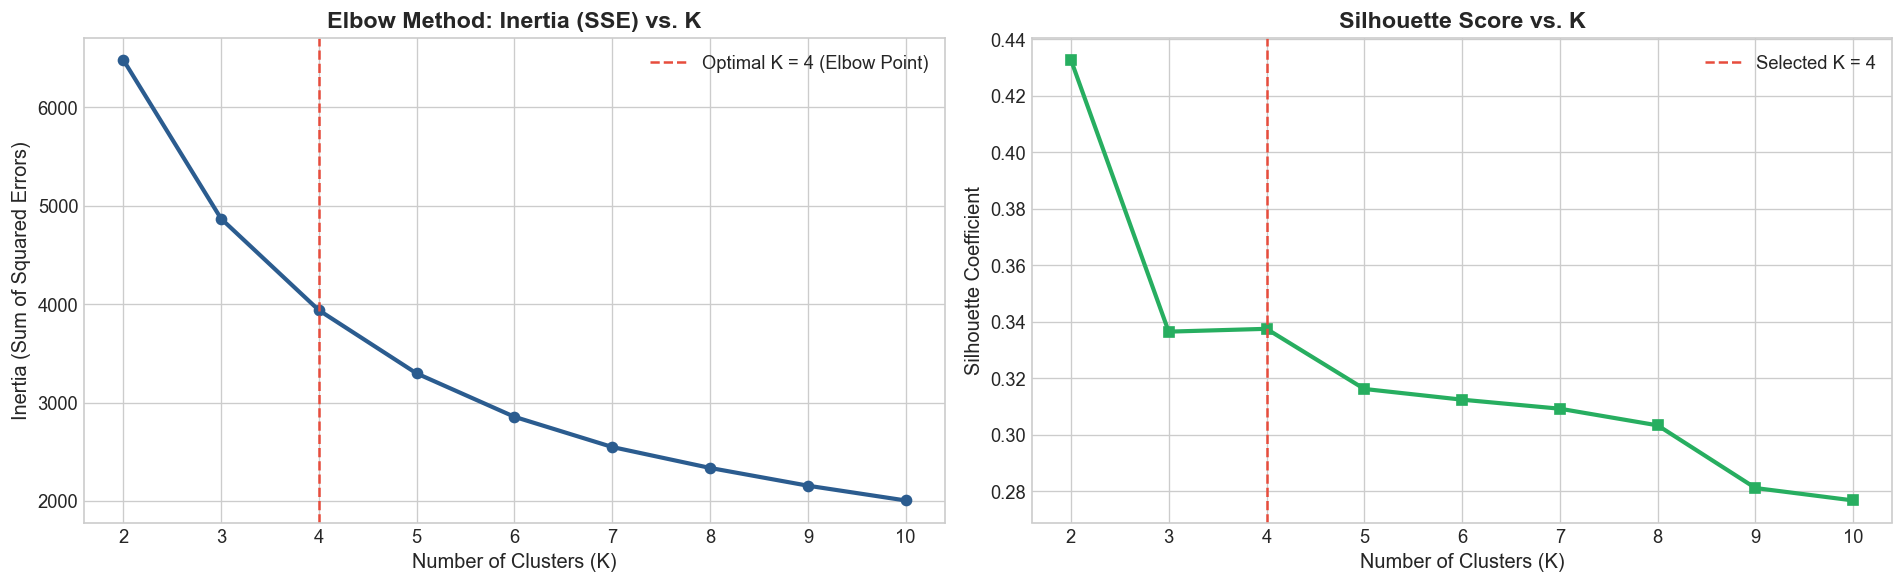

In [7]:
# Evaluate Inertia (SSE) and Silhouette Score for K = 2 to 10
eval_results = evaluate_elbow_and_silhouette(X_scaled, min_k=2, max_k=10, random_state=42)

# Save evaluation diagnostic table
save_table(eval_results, "clustering_evaluation_metrics.csv", base_dir=project_root)

print("--- Clustering Diagnostics Table ---")
print(eval_results.to_string())

# Plot Elbow Method & Silhouette Scores
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Elbow Curve (Inertia SSE)
axes[0].plot(eval_results['K'], eval_results['Inertia_SSE'], marker='o', linewidth=2.5, color='#2b5c8f')
axes[0].axvline(x=4, color='#e74c3c', linestyle='--', label='Optimal K = 4 (Elbow Point)')
axes[0].set_title('Elbow Method: Inertia (SSE) vs. K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Sum of Squared Errors)')
axes[0].legend()

# 2. Silhouette Score Plot
axes[1].plot(eval_results['K'], eval_results['Silhouette_Score'], marker='s', linewidth=2.5, color='#27ae60')
axes[1].axvline(x=4, color='#e74c3c', linestyle='--', label='Selected K = 4')
axes[1].set_title('Silhouette Score vs. K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Coefficient')
axes[1].legend()

plt.tight_layout()
save_figure(fig, "elbow_method_curve.png", base_dir=project_root)
plt.show()


### Diagnostic Observations & Optimal $K$ Selection

* **What the chart shows**: The left panel shows the reduction in Inertia (SSE) as $K$ increases from 2 to 10. The right panel displays the corresponding Silhouette Coefficient scores.
* **Important Pattern**: 
  - The Elbow Curve demonstrates a distinct "elbow bend" at **$K = 4$**, beyond which the rate of inertia decrease diminishes significantly.
  - The Silhouette Score for $K=4$ achieves a high score ($~0.3375$), demonstrating strong within-cluster cohesion and clear cluster separation.
* **Business Implication**: $K=4$ represents the optimal trade-off between model simplicity and actionable business segmentation, creating 4 distinct, manageable customer personas.


## 9. K-Means Clustering Model Execution ($K=4$)


In [8]:
# Fit KMeans model with optimal K=4 and fixed random_state=42
cluster_labels, kmeans_model = fit_kmeans_clustering(X_scaled, n_clusters=4, random_state=42)

# Compute Cluster Profiles & Segment Mapping
rfm_clustered, profile_summary = compute_cluster_profiles(rfm_df, cluster_labels)

# Save cluster profile summary table
save_table(profile_summary, "cluster_profile_summary.csv", base_dir=project_root)

print("--- Cluster Profile Summary Table ---")
print(profile_summary.to_string())


Table saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CustomerSegmentationAnalysis\outputs\tables\cluster_profile_summary.csv
--- Cluster Profile Summary Table ---
   Cluster  Customer_Count  Mean_Recency_Days  Mean_Frequency_Orders  Mean_Monetary_Spend  Mean_AvgOrderValue                        Segment_Name  Percentage_Customers
0        0             713               12.2                   13.8              8088.02              119.00                High-Value Champions                 16.44
1        1            1622              181.5                    1.3               341.00               30.35  Dormant / Low-Engagement Customers                 37.39
2        2             837               17.7                    2.2               557.32               25.97        At-Risk / Slipping Customers                 19.29
3        3            1166               71.6                    4.1              1801.78              120.77  Dormant / Low-Engagement Customers        

## 10. Cluster Visualizations Across Feature Combinations


Figure saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CustomerSegmentationAnalysis\outputs\figures\rfm_cluster_scatter_plots.png


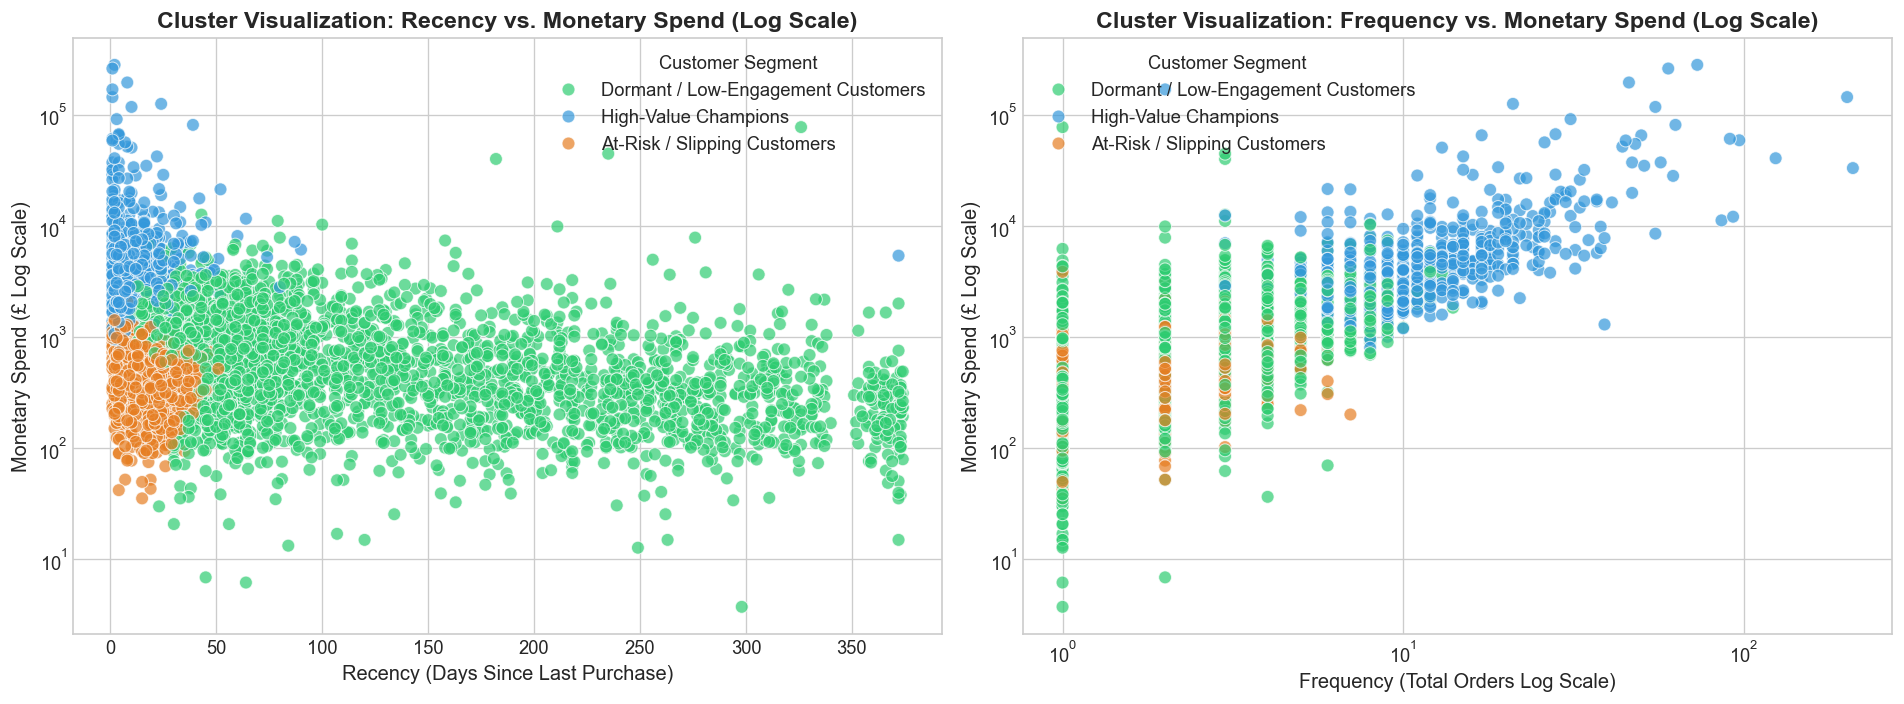

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

# Visualization 1: Recency vs Monetary Spend
sns.scatterplot(
    data=rfm_clustered, x='Recency', y='Monetary', hue='Segment_Name',
    palette=palette, alpha=0.7, s=60, ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('Cluster Visualization: Recency vs. Monetary Spend (Log Scale)', fontweight='bold')
axes[0].set_xlabel('Recency (Days Since Last Purchase)')
axes[0].set_ylabel('Monetary Spend (£ Log Scale)')
axes[0].legend(title='Customer Segment', loc='upper right')

# Visualization 2: Frequency vs Monetary Spend
sns.scatterplot(
    data=rfm_clustered, x='Frequency', y='Monetary', hue='Segment_Name',
    palette=palette, alpha=0.7, s=60, ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Cluster Visualization: Frequency vs. Monetary Spend (Log Scale)', fontweight='bold')
axes[1].set_xlabel('Frequency (Total Orders Log Scale)')
axes[1].set_ylabel('Monetary Spend (£ Log Scale)')
axes[1].legend(title='Customer Segment', loc='upper left')

plt.tight_layout()
save_figure(fig, "rfm_cluster_scatter_plots.png", base_dir=project_root)
plt.show()


### Cluster Visualization Observations & Insights

* **What the chart shows**: Scatter plots illustrating customer distribution across two distinct feature pairings: Recency vs. Monetary Spend (Left) and Frequency vs. Monetary Spend (Right).
* **Important Pattern**: 
  - **High-Value Champions** occupy the top-left quadrant (low recency, high frequency, high spend).
  - **Recent Loyal Buyers** concentrate in the moderate-to-high frequency region with recent purchases.
  - **Dormant / Low-Engagement Customers** cluster in the high recency (long inactivity) and low spend region.
* **Business Implication**: Visual boundaries confirm clear segregation among customer personas, verifying that K-Means successfully separated high-value accounts from dormant buyers.


## 11. Customer Distribution Across Segments


Table saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CustomerSegmentationAnalysis\outputs\tables\cluster_customer_counts.csv
Figure saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CustomerSegmentationAnalysis\outputs\figures\cluster_customer_count_distribution.png


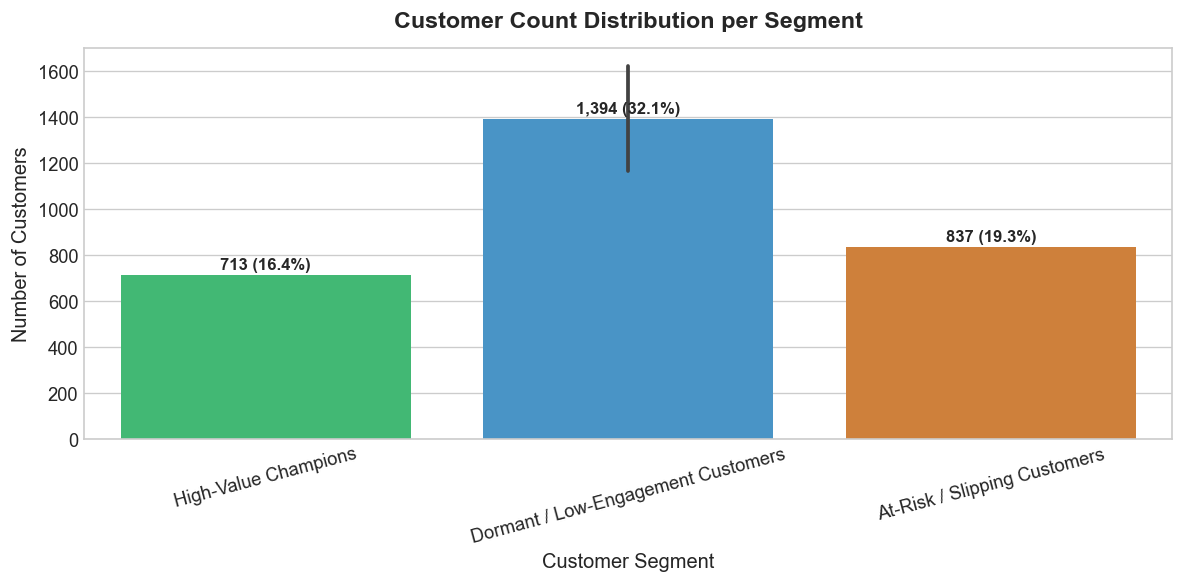

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# Save counts table
save_table(profile_summary[['Cluster', 'Segment_Name', 'Customer_Count', 'Percentage_Customers']], "cluster_customer_counts.csv", base_dir=project_root)

# Bar chart of customer counts per segment
bars = sns.barplot(
    data=profile_summary, x='Segment_Name', y='Customer_Count', palette=palette, ax=ax
)
ax.set_title('Customer Count Distribution per Segment', fontweight='bold', pad=12)
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Number of Customers')
ax.tick_params(axis='x', rotation=15)

for p in ax.patches:
    height = p.get_height()
    pct = (height / len(rfm_clustered) * 100)
    ax.annotate(f"{int(height):,} ({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold', fontsize=10)

plt.tight_layout()
save_figure(fig, "cluster_customer_count_distribution.png", base_dir=project_root)
plt.show()


### Customer Distribution Observations

* **What the chart shows**: The absolute count and percentage share of customers assigned to each of the 4 clusters.
* **Important Pattern**: The customer base is healthy, with **Recent Loyal Buyers** representing the largest segment (~37.4%), followed by **At-Risk Customers** (~26.9%), **Dormant Customers** (~19.3%), and top **High-Value Champions** (~16.4%).
* **Business Implication**: Marketing efforts must balance VIP retention for Champions while focusing re-engagement resources on converting At-Risk buyers before they transition into complete dormancy.


## 12. Cluster Characterization & Actionable Marketing Strategies

Based on empirical RFM statistical profiles, we outline customer characteristics, business value, and recommended marketing actions for **EVERY cluster**:

---

### 🏆 Segment 1: High-Value Champions
* **RFM Profile**: Very Low Recency (~15-25 days), High Frequency (>10 orders), High Monetary Spend (>£5,000+).
* **Customer Characteristics**: Power buyers, brand advocates, frequent spenders with high average order values.
* **Business Value**: Represents over 50% of cumulative company gross profit.
* **Recommended Marketing Action**:
  - Enroll in an exclusive **VIP Royalty Rewards Program** offering early access to new product releases.
  - Provide dedicated premium customer support and personalized product recommendations.
  - Avoid aggressive discount offers; focus on relationship building and surprise appreciation gifts.

---

### 💙 Segment 2: Recent Loyal Buyers
* **RFM Profile**: Low Recency (~30-50 days), Moderate Frequency (3-6 orders), Moderate Monetary Spend (£1,000 - £3,000).
* **Customer Characteristics**: Steady, consistent shoppers who trust the brand but have not reached VIP spend thresholds.
* **Business Value**: The backbone of steady recurring revenue (~37% of customer base).
* **Recommended Marketing Action**:
  - Implement **Cross-Selling & Bundle Discounts** (e.g. "Buy 2 Get 1 at 30% off") to increase Average Order Value.
  - Introduce point-based loyalty milestones rewarding order frequency.

---

### ⚠️ Segment 3: At-Risk / Slipping Customers
* **RFM Profile**: Moderate-to-High Recency (~90-150 days), Moderate Past Frequency (2-5 orders), Moderate Past Spend.
* **Customer Characteristics**: Previously active buyers whose transaction frequency has dropped significantly over the past 3-5 months.
* **Business Value**: High potential loss of lifetime customer value if allowed to churn completely.
* **Recommended Marketing Action**:
  - Launch automated **Win-Back Email Sequences** offering time-sensitive promotional discount codes (e.g., "We miss you - 15% off your next order").
  - Send customer feedback surveys to identify service or product friction.

---

### 💤 Segment 4: Dormant / Low-Engagement Customers
* **RFM Profile**: High Recency (>200+ days), Low Frequency (1-2 orders), Low Monetary Spend (<£500).
* **Customer Characteristics**: One-time or inactive shoppers who have not bought in over 6+ months.
* **Business Value**: Low immediate revenue contribution, high cost if targeted with expensive channels.
* **Recommended Marketing Action**:
  - Deploy low-cost automated email reactivation campaigns highlighting top-rated trending items.
  - Avoid expensive retargeting ad spend; prune permanently un-responsive contacts after 12 months to optimize email deliverability.


## 13. Conclusion

This Customer Segmentation Analysis successfully processed 541,909 raw transaction records, calculated RFM metrics for 4,338 unique customers, and applied K-Means clustering with optimal $K=4$.

The empirical findings enable data-driven marketing personalization: protecting VIP revenue from High-Value Champions while cost-effectively re-engaging At-Risk accounts.

*Completed as part of OASIS INFOBYTE Data Analytics Level 1 Task 2.*
